  **Cvičení 14 - Lokalizace epileptických ložisek**

V průběhu semestru jste se seznámili se základy práce s datovými soubory a s elementárními programovacími postupy. V dnešním cvičení tyto znalosti uplatníte při řešení úlohy zaměřené na vyhledávání epileptických ložisek z intrakraniálního EEG (iEEG) – tedy záznamu elektrické aktivity snímané přímo z mozkové tkáně. Tento typ měření se používá jako součást předoperačního vyšetření u pacientů s farmakorezistentní epilepsií.

Během práce můžete využívat nástroje umělé inteligence pro generování kódu (např. ChatGPT, Gemini, Claude aj.). Je však nutné, abyste rozuměli principům a funkci kódu, který vám tyto nástroje nabídnou.

Úloha je koncipována tak, aby co nejvíce simulovala reálnou práci ve výzkumném týmu, který se zabývá výpočetní neurovědou. Vaším cílem bude navrhnout a implementovat postup zpracování iEEG dat, který povede k identifikaci oblastí potenciálně odpovědných za vznik epileptických záchvatů.

EEG data se mohou ukládat v různých formátech. Jeden z nejvíce používaných je .edf file. Například zde: https://openneuro.org/ můžete najít různé databáze neurologických MRI a EEG dat.

V dnešní hodině využijete reaálná iEEG data, která jsou uložena v přiloženém sbouboru EEG.edf. Informace o souřadnicích elektrod jsou přiložené v electrodes.tsv souboru.

**Cíle**
1) Načtěte electrodes.tsv soubor a vypište obsah souboru
2) Jaké sloupce soubor obsahuje ?
3) Využijte knihovnu nilearn a zobrazte model mozku a souřadnice implantovaných elektrod. (https://nilearn.github.io/dev/modules/generated/nilearn.plotting.plot_markers.html)
4) Vypište pozice resekovaných elektrod "RES"=TRUE
5) Využijte objekt AtlasLabeler, který určí anatomické názvy implantovaných struktur na základě MNI souřadnic, sloupce "R","A","S".
6) Načtěte přiložený .edf soubor, který obsahuje EEG data
7) Vypište délku EEG nahrávky (počet sekund), počet měřených vzorků, počet měřených kanálů. Zobrazte 30 sekund z kanálu B'1 - B'5
8) Vypočítejte výkon EEG signálu v pásmu Beta (12-30 Hz) pro každý kanál
9) Vypočítejte výkon EEG signálu v pásmu Delta (1-4 Hz) pro každý kanál
10) vypočítejte poměr delta/beta, který může ukazovat na epileptické ložisko.
11) Seřaďte kanály podle výsledného delta_beta_ratio. Vypište Top-20 kanálů s největším delta/beta poměrem.
12) Vypočítejte kolik z nich bylo chirurgicky odstraněno.



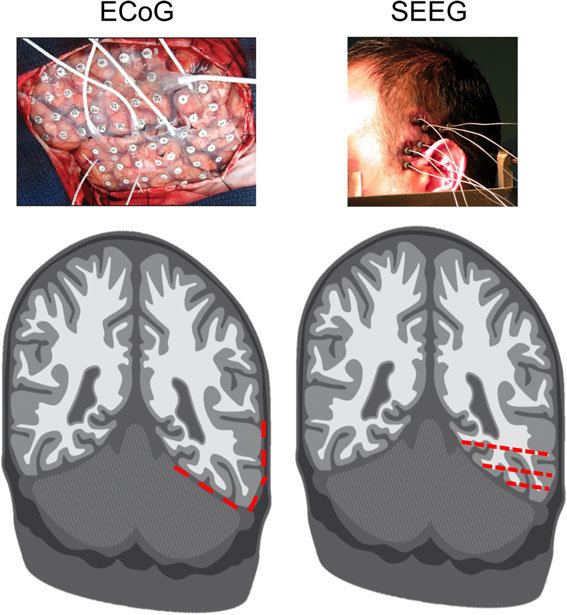

In [31]:
from IPython.display import Image, display

display(Image(filename='iEEG_img.jpeg'))

In [32]:
# Využijte knihovny definované níže
# V případě potřeby si doinstalujte další potřebné knihovny
# Instalace potřebných knihoven v Google Colab
!pip install nilearn
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install nibabel
!pip install mne
!pip install scipy

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import plotting, datasets
import nibabel as nib
import matplotlib.pyplot as plt


In [34]:
# --------------------------------------------------------
# 1) Načtení electrodes.tsv soubor a vypište obsah souboru
# --------------------------------------------------------

# Implementujte načtení .tsv souboru pomocí pandas
df = pd.read_csv('electrodes.tsv', sep='\t')
print(df.to_string())

    channel     R     A     S    RES
0       B'1 -21.0 -17.0 -19.0   True
1       B'2 -24.6 -17.0 -19.4   True
2       B'3 -28.1 -17.0 -19.9   True
3       B'4 -31.7 -17.0 -20.3   True
4       B'5 -35.2 -17.0 -20.8   True
5       B'6 -38.8 -17.0 -21.2   True
6       B'7 -42.3 -17.0 -21.7   True
7       B'8 -45.9 -17.0 -22.1  False
8       B'9 -49.4 -17.0 -22.6  False
9      B'10 -53.0 -17.0 -23.0  False
10     B'11 -56.6 -17.0 -23.4  False
11     B'12 -60.1 -17.0 -23.9  False
12     B'13 -63.7 -17.0 -24.3  False
13     B'14 -67.2 -17.0 -24.8  False
14     B'15 -70.8 -17.0 -25.2  False
15      C'1 -27.0 -29.0  -9.0  False
16      C'2 -30.6 -29.1  -9.4  False
17      C'3 -34.1 -29.2  -9.9  False
18      C'4 -37.7 -29.3 -10.3  False
19      C'5 -41.2 -29.4 -10.8  False
20      C'6 -44.8 -29.6 -11.2  False
21      C'7 -48.3 -29.7 -11.7  False
22      C'8 -51.9 -29.8 -12.1  False
23      C'9 -55.4 -29.9 -12.6  False
24     C'10 -59.0 -30.0 -13.0  False
25     C'11 -62.6 -30.1 -13.4  False
2

In [35]:
# --------------------------------------------------------
# 2) Jaké sloupce soubor obsahuje ?
# --------------------------------------------------------

print(df.columns)

Index(['channel', 'R', 'A', 'S', 'RES'], dtype='object')


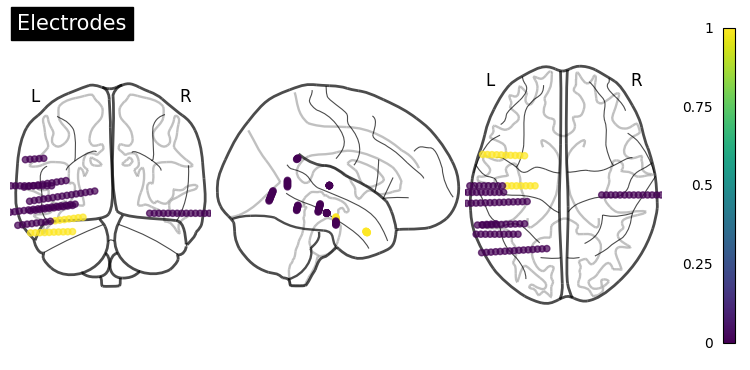

In [36]:
# --------------------------------------------------------
# 3) Využijte knihovnu nilearn a zobrazte model mozku a souřadnice implantovaných elektrod.
#  (https://nilearn.github.io/dev/modules/generated/nilearn.plotting.plot_markers.html)
# --------------------------------------------------------

# Vytvořte glassbrain plot, kde jsou zobrazené SEEG elektrody
coords = df[['R', 'A', 'S']].values
plotting.plot_markers(node_values=df['RES'].values, node_coords=coords, title='Electrodes',node_size=20, node_cmap='viridis')
plt.show()


In [37]:
# --------------------------------------------------------
# 4) Vypište pozice resekovaných elektrod "RES"=TRUE
# --------------------------------------------------------
res_df = df[df['RES'] == True]
print(res_df.to_string())

   channel     R     A     S   RES
0      B'1 -21.0 -17.0 -19.0  True
1      B'2 -24.6 -17.0 -19.4  True
2      B'3 -28.1 -17.0 -19.9  True
3      B'4 -31.7 -17.0 -20.3  True
4      B'5 -35.2 -17.0 -20.8  True
5      B'6 -38.8 -17.0 -21.2  True
6      B'7 -42.3 -17.0 -21.7  True
45     A'1 -29.0   6.0 -30.0  True
46     A'2 -32.6   6.1 -30.1  True
47     A'3 -36.1   6.2 -30.2  True
48     A'4 -39.7   6.3 -30.3  True
49     A'5 -43.2   6.4 -30.4  True
50     A'6 -46.8   6.6 -30.6  True
51     A'7 -50.3   6.7 -30.7  True
52     A'8 -53.9   6.8 -30.8  True
53     A'9 -57.4   6.9 -30.9  True
54    A'10 -61.0   7.0 -31.0  True


In [38]:
# --------------------------------------------------------
# 5) Využijte objekt AtlasLabeler, který určí anatomické názvy implantovaných struktur na základě MNI souřadnic, sloupce "R","A","S".
# Využijte AtlasLabeler objekt, který si můžete importovat z atlas_labeler.py.
# --------------------------------------------------------
# Pro odvážné: můžete si vytvořit vlastní AtlasLabeler objekt, který načte atlasy z balíku nilearn.
# objekt je založen na principu kdy zadám MNI souřadnice a objekt vrací anatomický název struktury.
# struktura = labeler((R,A,S))
# --------------------------------------------------------

from atlas_labeler import AtlasLabeler
labeler = AtlasLabeler()

for index, row in res_df.iterrows():
  coord = (row['R'], row['A'], row['S'])
  structure = labeler(coord)
  print(f"Electrode {row['channel']}: {structure}")

Loading Harvard-Oxford Atlases...
[fetch_atlas_harvard_oxford] Dataset found in /Users/pnejedly/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /Users/pnejedly/nilearn_data/fsl
Electrode B'1: Left Hippocampus
Electrode B'2: Left Hippocampus
Electrode B'3: Left Hippocampus
Electrode B'4: Left Hippocampus
Electrode B'5: Left Cerebral White Matter
Electrode B'6: Temporal Fusiform Cortex, posterior division
Electrode B'7: Temporal Fusiform Cortex, posterior division
Electrode A'1: Temporal Pole
Electrode A'2: Temporal Pole
Electrode A'3: Left Cerebral White Matter
Electrode A'4: Left Cerebral White Matter
Electrode A'5: Temporal Pole
Electrode A'6: Temporal Pole
Electrode A'7: Temporal Pole
Electrode A'8: Temporal Pole
Electrode A'9: Temporal Pole
Electrode A'10: No label (background)


In [39]:
# --------------------------------------------------------
# 6) Načtěte přiložený .edf soubor, který obsahuje EEG data
# --------------------------------------------------------

import mne

# Path to your EDF file
edf_file_path = 'EEG.edf'

# Load the EDF file
raw = mne.io.read_raw_edf(edf_file_path, preload=True)

# Print information about the loaded data
print("------------------------------")
print("Header:")
print(raw.info)
print("------------------------------")

# Jména kanálů
channel_names = raw.ch_names
print("Channel names:", channel_names)

# Poček kanálů
n_channels = raw.info['nchan']
print("Number of channels:", n_channels)

# Vzorkovací frekvence
fsamp = raw.info['sfreq']
print("Sampling frequency:", fsamp)

# Délka signálu vzorků
n_samples = raw.n_times
print("Number of samples:", n_samples)

# Délka signálu sekundy

duration = n_samples / fsamp
print("Duration (seconds):", duration)

Extracting EDF parameters from EEG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 149999  =      0.000 ...   299.998 secs...
------------------------------
Header:
<Info | 8 non-empty values
 bads: []
 ch_names: B'1, B'2, B'3, B'4, B'5, B'6, B'7, B'8, B'9, B'10, B'11, B'12, ...
 chs: 119 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: 2013-03-06 08:37:15 UTC
 nchan: 119
 projs: []
 sfreq: 500.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
------------------------------
Channel names: ["B'1", "B'2", "B'3", "B'4", "B'5", "B'6", "B'7", "B'8", "B'9", "B'10", "B'11", "B'12", "B'13", "B'14", "B'15", "C'1", "C'2", "C'3", "C'4", "C'5", "C'6", "C'7", "C'8", "C'9", "C'10", "C'11", "C'12", "C'13", "C'14", "C'15", "R'1", "R'2", "R'3", "R'4", "R'5", "R'6", "R'7", "R'8", "R'9", "R'10", "R'11", "R'12", "R'13", "R'14", "R'15", 'A12A', "A'1", "A'2", "A'3", "A'4", "A'5", "A'6", "A'7", "A'8", "A'9", "A'10", "L'

První vzorek: 0
Poslední vzorek: 15000
Čísla kanálů: [0, 1, 2, 3, 4, 5]
Data matrix shape: (6, 15000)


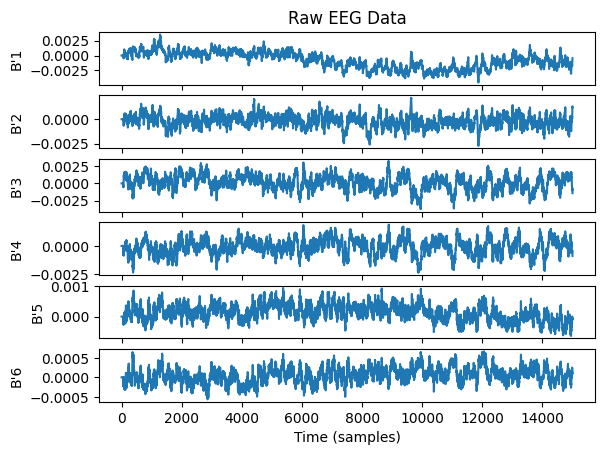

In [40]:
# --------------------------------------------------------
# 6) Zobrazte prvních 30 sekund dat z kanálu B'1 až B'6 pomocí matplotlib a funkce subplots()
# --------------------------------------------------------

sample_start = int(0)
sample_stop = int(30 * fsamp)
channel_indexes = [raw.ch_names.index(f"B'{i}") for i in range(1, 7)]
print("První vzorek:",sample_start)
print("Poslední vzorek:",sample_stop)
print("Čísla kanálů:",channel_indexes)



data = raw.get_data()
data = data[channel_indexes, sample_start:sample_stop]
print("Data matrix shape:",data.shape)

fig,ax = plt.subplots(6,1)
for i in range(data.shape[0]):
    ax[i].plot(data[i,:])
    ax[i].set_ylabel(raw.ch_names[channel_indexes[i]])
ax[5].set_xlabel('Time (samples)')
ax[0].set_title('Raw EEG Data')
plt.show()

In [43]:
# ------------------------------------------
# 8) Vypočítejte výkon EEG signálu v pásmu Beta (12-30 Hz) pro každý kanál
# 9) Vypočítejte výkon EEG signálu v pásmu Delta (1-4 Hz) pro každý kanál
# Vyžijte knihovnu scipy, která poskytuje funkce na filtrování signálu
# ------------------------------------------

from scipy.signal import butter,filtfilt

def compute_signal_power(data, fs, f0, f1):
  B,A = butter(3,[f0/(fs/2), f1/(fs/2)],'bandpass')
  x = filtfilt(B,A,data)
  return np.mean(x**2)


def compute_delta_power(data, fs):
  return compute_signal_power(data, fs, 1, 4)

def compute_beta_power(data, fs):
  return compute_signal_power(data, fs, 12, 30)


for i,row in df.iterrows():
  data = raw.get_data()[raw.ch_names.index(row['channel']), :]
  delta_power = compute_delta_power(data, fsamp)
  beta_power = compute_beta_power(data, fsamp)
  df.at[i, 'delta_power'] = delta_power
  df.at[i, 'beta_power'] = beta_power
  df.at[i, 'delta_beta_ratio'] = delta_power / beta_power


print(df.to_string())


    channel     R     A     S    RES   delta_power    beta_power  delta_beta_ratio
0       B'1 -21.0 -17.0 -19.0   True  6.775550e-07  1.897623e-07          3.570546
1       B'2 -24.6 -17.0 -19.4   True  7.822362e-07  1.541613e-07          5.074142
2       B'3 -28.1 -17.0 -19.9   True  1.242970e-06  2.518311e-07          4.935729
3       B'4 -31.7 -17.0 -20.3   True  6.951818e-07  1.421269e-07          4.891275
4       B'5 -35.2 -17.0 -20.8   True  7.324350e-08  2.331239e-08          3.141826
5       B'6 -38.8 -17.0 -21.2   True  4.174135e-08  1.055261e-08          3.955547
6       B'7 -42.3 -17.0 -21.7   True  3.205218e-08  7.360710e-09          4.354495
7       B'8 -45.9 -17.0 -22.1  False  2.955299e-08  8.091791e-09          3.652219
8       B'9 -49.4 -17.0 -22.6  False  2.524969e-08  9.039028e-09          2.793408
9      B'10 -53.0 -17.0 -23.0  False  2.805697e-08  1.211249e-08          2.316367
10     B'11 -56.6 -17.0 -23.4  False  3.433298e-08  1.531353e-08          2.242003
11  

In [45]:
# --------------------------------------------------------
# 11) Seřaďte kanály podle výsledného delta_beta_ratio. Vypište Top-20 kanálů s největším delta/beta poměrem.
# --------------------------------------------------------  
df = df.sort_values(by='delta_beta_ratio', ascending=False)
print(df.head(20).to_string(index=False))

channel     R     A     S   RES  delta_power   beta_power  delta_beta_ratio
    B12  68.5 -24.0 -16.0 False 1.313495e-06 3.883511e-08         33.822348
    A'5 -43.2   6.4 -30.4  True 1.354236e-07 8.286817e-09         16.342051
    A'2 -32.6   6.1 -30.1  True 1.572014e-07 1.089564e-08         14.427922
    A'4 -39.7   6.3 -30.3  True 1.354591e-07 1.142526e-08         11.856109
    T'8 -69.1 -22.0   5.0 False 6.268248e-08 5.294367e-09         11.839467
    A'6 -46.8   6.6 -30.6  True 1.120628e-07 1.336785e-08          8.383010
    A'3 -36.1   6.2 -30.2  True 1.423911e-07 2.130474e-08          6.683541
    B'2 -24.6 -17.0 -19.4  True 7.822362e-07 1.541613e-07          5.074142
    B'3 -28.1 -17.0 -19.9  True 1.242970e-06 2.518311e-07          4.935729
    B'4 -31.7 -17.0 -20.3  True 6.951818e-07 1.421269e-07          4.891275
     B3  37.0 -24.0 -16.0 False 1.937543e-07 4.366223e-08          4.437572
     B2  33.5 -24.0 -16.0 False 1.922148e-07 4.334923e-08          4.434100
    B'7 -42.

In [ ]:
# -------------------------------------------
# 12) Vypočítejte kolik z nich bylo chirurgicky odstraněno.
# -------------------------------------------

resected_top_20 = df.head(20)['RES'].sum()
print(f"Top-20 kanálů, které byly vybrané na základě našeho algoritmu (podle hodnoty Delta/Beta), které byly chirurgicky odstraněny: {resected_top_20}")

total_resected = df['RES'].sum()
print(f"Celkem kanálů, které byly chirurgicky odstraněny: {total_resected}")

total_channels = df['RES'].count()
print(f"Celkem kanálů: {total_channels}")

Top-20 kanálů, které byly vybrané na základě našeho algoritmu (podle hodnoty Delta/Beta), které byly chirurgicky odstraněny: 13
Celkem kanálů, které byly chirurgicky odstraněny: 17
Celkem kanálů: 105


In [48]:
# Co zapříčinilo, že největší hodnota Delta/Beta je ustřelená od ostatních hodnot? 
